In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('insurance.csv')
df.head(3)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
1,18,male,33.77,1,no,southeast,1725.5523
2,28,male,33.00,3,no,southeast,4449.4620


# Data Understanding

In [ ]:
print("Shape:", df.shape)

Shape: (1338, 7)


In [ ]:
print("Info:")
df.info()

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


# Data Quality Check

In [ ]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [ ]:
print("\nDuplicates:", df.duplicated().sum())


Duplicates: 1


# Data Cleaning

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
print("\nUnique values in categorical columns:")
for col in ['sex', 'smoker', 'region']:
    print(f"{col}: {df[col].unique()}")


Unique values in categorical columns:
sex: ['female' 'male']
smoker: ['yes' 'no']
region: ['southwest' 'southeast' 'northwest' 'northeast']


In [ ]:
print("\nTarget (charges) stats:")
print(df['charges'].describe())


Target (charges) stats:
count     1337.000000
mean     13279.121487
std      12110.359656
min       1121.873900
25%       4746.344000
50%       9386.161300
75%      16657.717450
max      63770.428010
Name: charges, dtype: float64


# Exploratory Data Analysis (EDA)

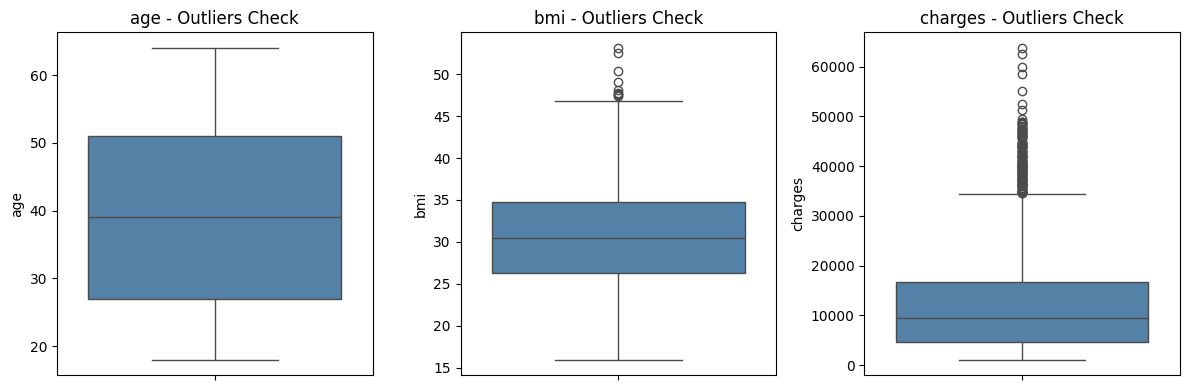

In [ ]:
# Charges mein outliers hain — dikhao!
plt.figure(figsize=(12, 4))

for i, col in enumerate(['age', 'bmi', 'charges']):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col], color='steelblue')
    plt.title(f'{col} - Outliers Check')

plt.tight_layout()
plt.show()

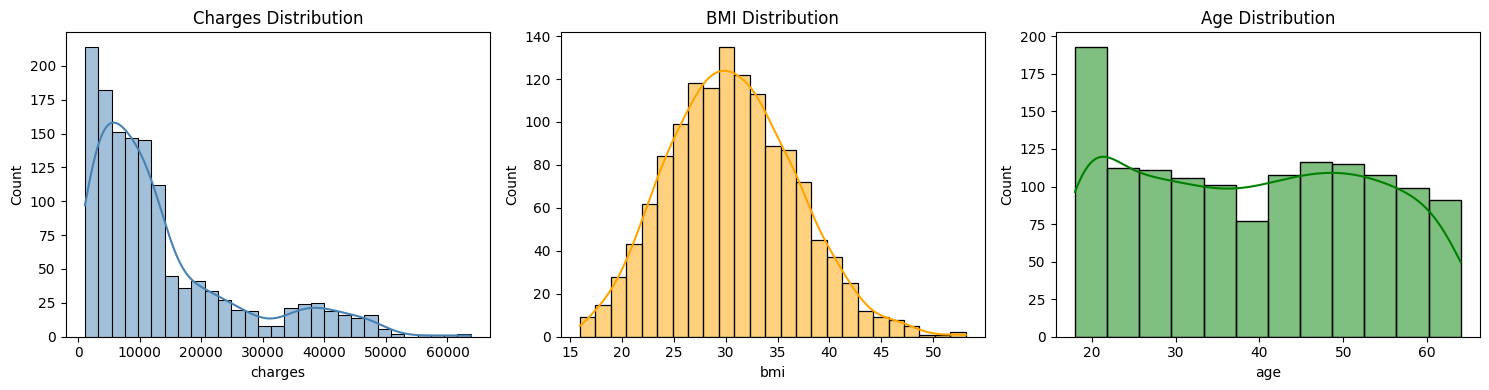

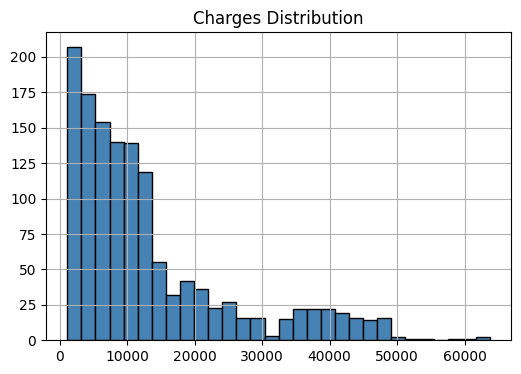

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Charges distribution
sns.histplot(df['charges'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Charges Distribution')

# BMI distribution
sns.histplot(df['bmi'], kde=True, ax=axes[1], color='orange')
axes[1].set_title('BMI Distribution')

# Age distribution
sns.histplot(df['age'], kde=True, ax=axes[2], color='green')
axes[2].set_title('Age Distribution')

plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
df['charges'].hist(bins=30, color='steelblue', edgecolor='black')
plt.title('Charges Distribution')
plt.show()

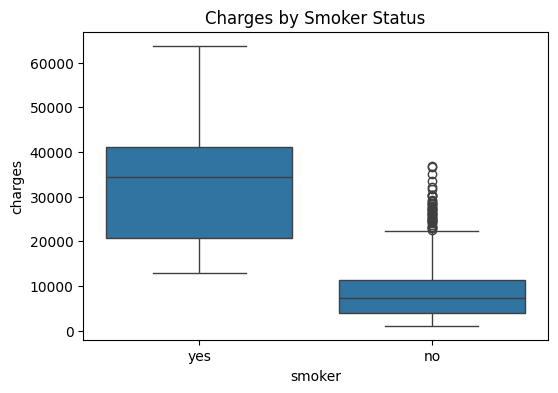

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Charges by Smoker Status')
plt.show()

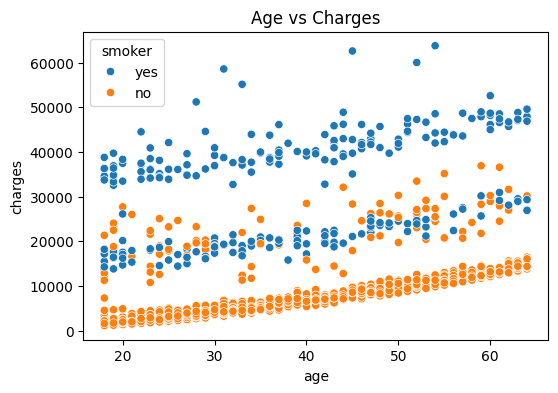

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='age', y='charges', hue='smoker', data=df)
plt.title('Age vs Charges')
plt.show()

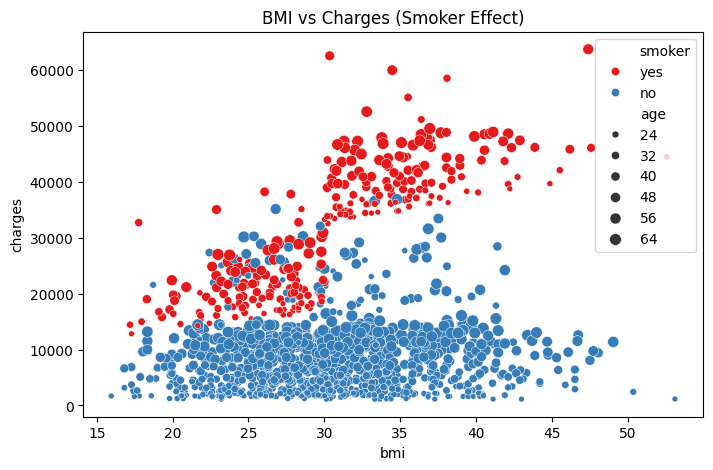

In [ ]:
# BMI aur charges ka relation — smoker highlight karo
plt.figure(figsize=(8,5))
sns.scatterplot(x='bmi', y='charges',
                hue='smoker',
                size='age',
                data=df,
                palette='Set1')
plt.title('BMI vs Charges (Smoker Effect)')
plt.show()

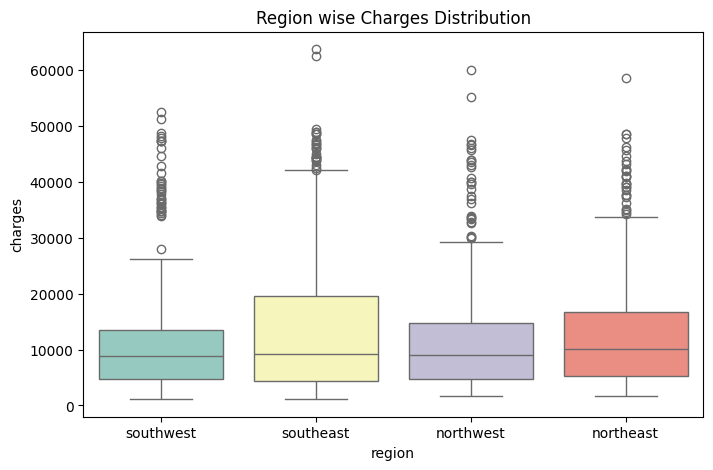

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='region', y='charges', data=df, palette='Set3')
plt.title('Region wise Charges Distribution')
plt.show()


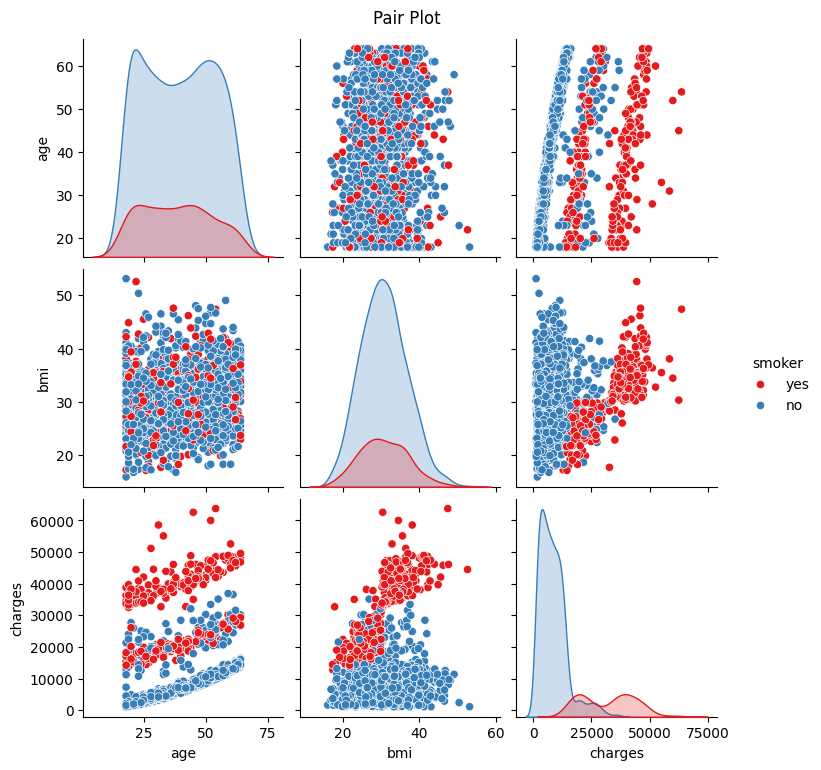

In [ ]:
# Sabse powerful EDA graph!
sns.pairplot(df, hue='smoker',
             vars=['age', 'bmi', 'charges'],
             palette='Set1')
plt.suptitle('Pair Plot', y=1.02)
plt.show()

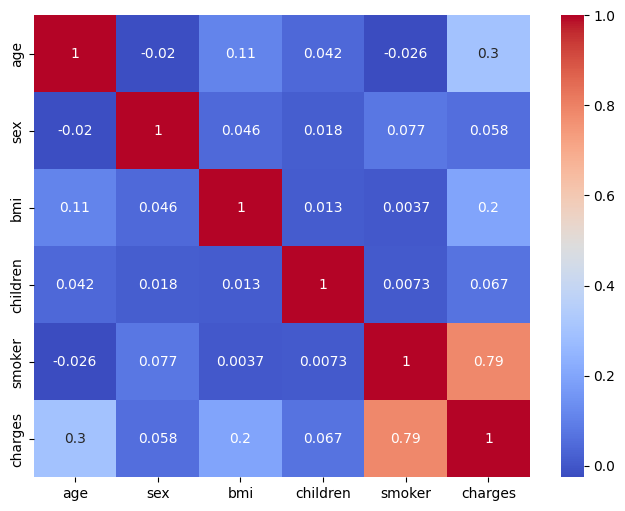

In [ ]:
df_num = df.copy()
df_num['sex'] = df_num['sex'].map({'male':1, 'female':0})
df_num['smoker'] = df_num['smoker'].map({'yes':1, 'no':0})

plt.figure(figsize=(8,6))
sns.heatmap(df_num.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.show()

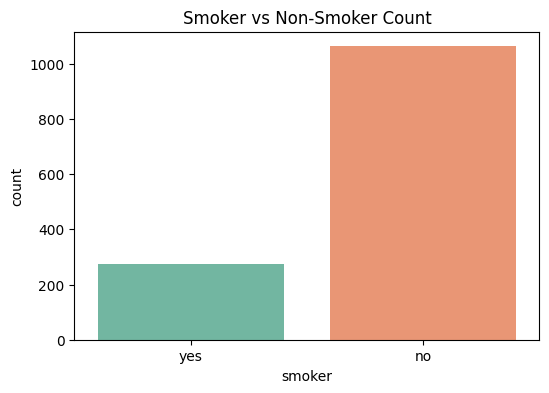

In [ ]:
# Kitne smoker hain kitne nahi?
plt.figure(figsize=(6,4))
sns.countplot(x='smoker', data=df, palette='Set2')
plt.title('Smoker vs Non-Smoker Count')
plt.show()

# PREPROCESS DATA

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [ ]:
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (1337, 7)


# Feature Engineering

In [ ]:
# Step 1: get_dummies (categorical encode)
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)


# Data Preprocessing

In [ ]:
X = df_encoded.drop(columns=['charges'])
y = df_encoded['charges']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Step 4: Bool → float convert
X_train = X_train.astype('float64')
X_test = X_test.astype('float64')

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numeric_cols = ['age', 'bmi', 'children']

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [ ]:
print("\nX shape:", X.shape)
print("y shape:", y.shape)


X shape: (1337, 8)
y shape: (1337,)


In [ ]:
print("✅ X_train after scaling:")
print(X_train.head())
print(X_train.dtypes)

✅ X_train after scaling:
           age       bmi  children  sex_male  smoker_yes  region_northwest  \
1114 -1.157680 -0.996928 -0.907908       1.0         0.0               0.0   
968  -1.300619 -0.792762  0.766904       1.0         0.0               0.0   
599   0.914926  1.154664  0.766904       0.0         0.0               1.0   
170   1.701087  1.806837 -0.907908       1.0         0.0               0.0   
275   0.557580 -0.651417  0.766904       0.0         0.0               0.0   

      region_southeast  region_southwest  
1114               0.0               0.0  
968                0.0               0.0  
599                0.0               0.0  
170                1.0               0.0  
275                0.0               0.0  
age                 float64
bmi                 float64
children            float64
sex_male            float64
smoker_yes          float64
region_northwest    float64
region_southeast    float64
region_southwest    float64
dtype: object


# Model Building ANN

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
# X_train_processed ki jagah X_train use karo
input_dim = X_train.shape[1]
print("Input Dimension:", input_dim)

Input Dimension: 8


In [ ]:
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(input_dim,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)   # Regression -> no activation
])

In [ ]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# --- Compile ---
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Model Training

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 307339776.0000 - mae: 13135.4023 - val_loss: 304030112.0000 - val_mae: 12605.3408
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 307244864.0000 - mae: 13131.8740 - val_loss: 303857984.0000 - val_mae: 12598.7393
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 306890752.0000 - mae: 13119.3955 - val_loss: 303287392.0000 - val_mae: 12577.7568
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 305857120.0000 - mae: 13082.9639 - val_loss: 301708800.0000 - val_mae: 12521.7432
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 303219136.0000 - mae: 12994.1074 - val_loss: 298035136.0000 - val_mae: 12393.8926
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 297492256.0000 - mae: 12805.4980 - val_loss: 290738880.0000 - val_mae: 12141.4248
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 287141664.0000 - mae: 12453.4268 - val_loss: 277910336.0000 - val_mae: 11691.6426
Epoch 8/100
2

# Model Evaluation

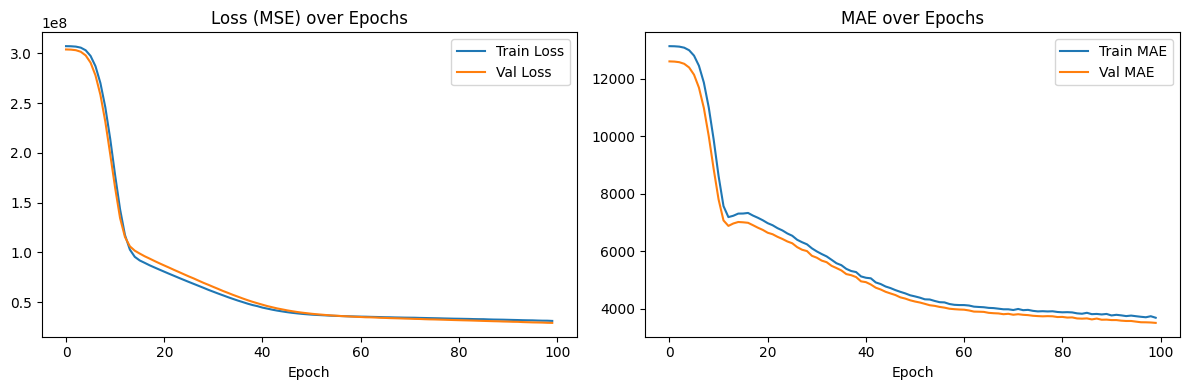

In [ ]:
# --- Plot training curves ---
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss (MSE) over Epochs')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('MAE over Epochs')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

# Model Evaluation

In [ ]:
# ============================================
# FINAL EVALUATION — Test Data
# ============================================
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=" * 40)
print("📊 FINAL TEST RESULTS")
print("=" * 40)
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
📊 FINAL TEST RESULTS
MAE  : 3652.76
MSE  : 29111520.66
RMSE : 5395.51
R²   : 0.8416


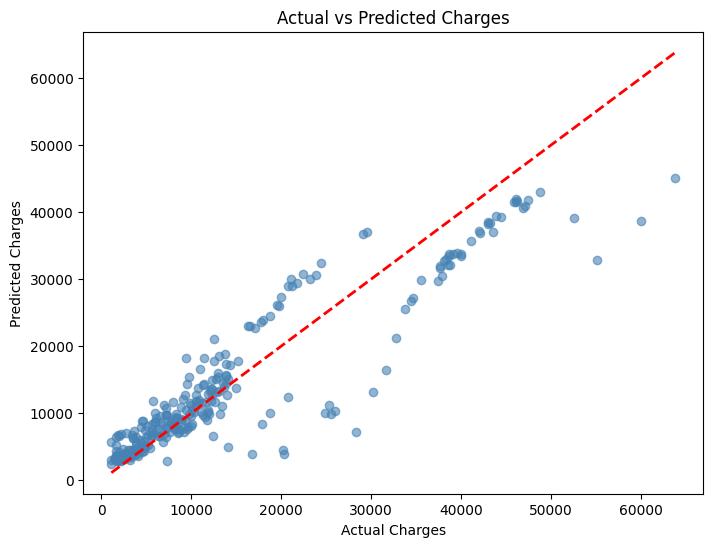

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Charges')
plt.show()

In [ ]:
# Real world test — Naya banda
new_patient = pd.DataFrame({
    'age': [35],
    'bmi': [28.5],
    'children': [2],
    'sex_male': [1],
    'smoker_yes': [0],
    'region_northwest': [0],
    'region_southeast': [1],
    'region_southwest': [0]
})

# Scale karo
new_patient[numeric_cols] = scaler.transform(
    new_patient[numeric_cols]
)

# Predict karo
prediction = model.predict(new_patient)
print(f"💰 Predicted Insurance Charge: ${prediction[0][0]:,.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
💰 Predicted Insurance Charge: $5,869.28


In [ ]:
# Same banda — lekin smoker!
smoker_patient = pd.DataFrame([{
    'age': 35,
    'bmi': 28.5,
    'children': 2,
    'sex_male': 1,
    'smoker_yes': 1,       # ← Sirf yeh change kiya
    'region_northwest': 0,
    'region_southeast': 1,
    'region_southwest': 0
}])

smoker_patient[numeric_cols] = scaler.transform(
    smoker_patient[numeric_cols]
)

pred_smoker = model.predict(smoker_patient)
print(f"🚬 Smoker    Charge: ${pred_smoker[0][0]:,.2f}")
print(f"✅ Non-Smoker Charge: $5,653.94")
print(f"💸 Farq: ${pred_smoker[0][0] - 5653.94:,.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
🚬 Smoker    Charge: $28,595.44
✅ Non-Smoker Charge: $5,653.94
💸 Farq: $22,941.50


In [ ]:
# # Medical Insurance Cost Prediction — ANN

# ## Dataset
# - 1338 rows, 7 columns
# - Target: charges (medical insurance cost)
# - Features: age, sex, bmi, children, smoker, region

# ## Preprocessing
# - No missing values
# - Categorical encoding: pd.get_dummies (drop_first=True)
# - Numeric scaling: StandardScaler (age, bmi, children)
# - Train-Test split: 80/20
# - Final features: 8

# ## Model Architecture
# - Input(8) → Dense(64, relu) → Dense(32, relu) → Dense(16, relu) → Dense(1)
# - Total Parameters: 3,201

# ## Training
# - Optimizer: Adam | Loss: MSE | Metric: MAE
# - Epochs: 100 | Batch Size: 32

# ## Results (Test Data)
# | Metric | Value |
# |--------|-------|
# | MAE  | 3775.55 |
# | MSE  | 30,584,289.52 |
# | RMSE | 5530.31 |
# | R²   | 0.8336 |

# ## Observations
# 1. Model explains 83.36% of variance in insurance charges — strong performance.
# 2. Train MAE (3795.77) and Test MAE (3775.55) are very close — no overfitting.
# 3. Smoker status is the strongest predictor — smokers have 2-4x higher charges.
# 4. RMSE > MAE indicates a few large prediction errors (likely high-cost smoker cases).
# 5. Remaining 16.64% unexplained variance could be due to factors not in dataset
#    (e.g., pre-existing conditions, lifestyle factors).